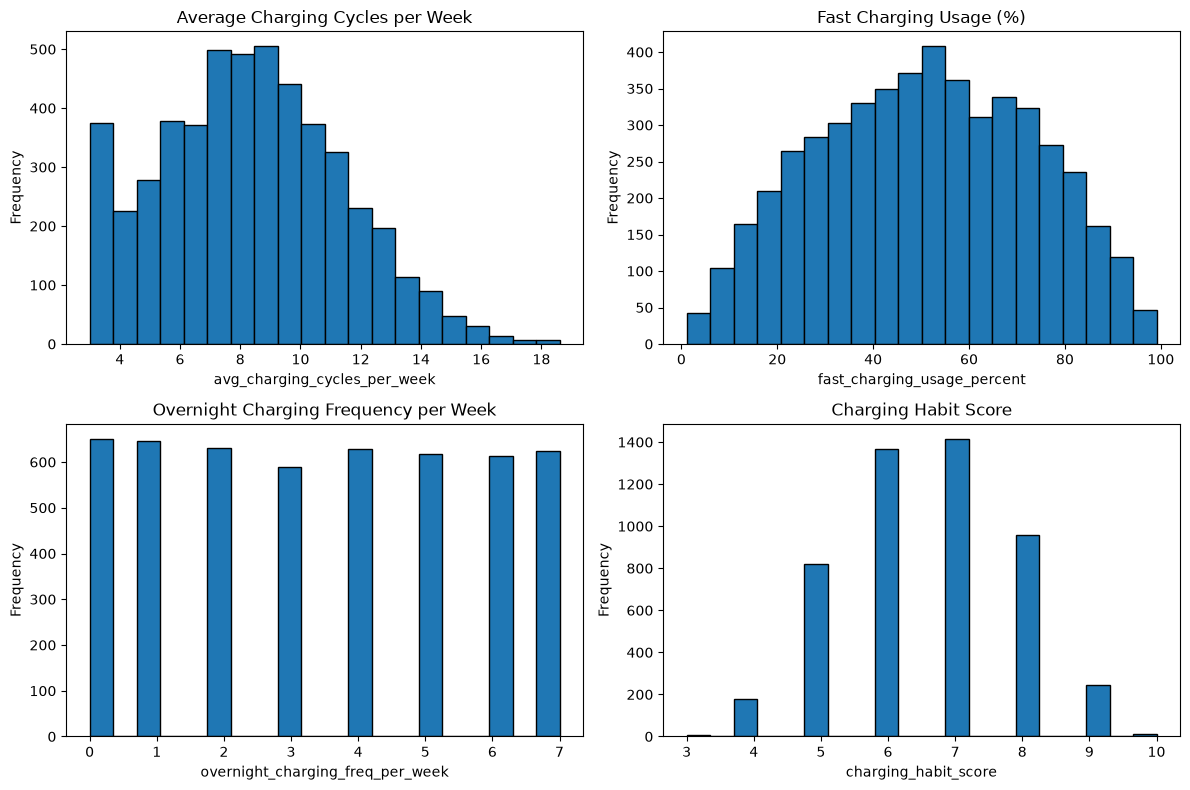

In [4]:
import matplotlib.pyplot as plt

charging_vars = [
    "avg_charging_cycles_per_week",
    "fast_charging_usage_percent",
    "overnight_charging_freq_per_week",
    "charging_habit_score"
]

titles = [
    "Average Charging Cycles per Week",
    "Fast Charging Usage (%)",
    "Overnight Charging Frequency per Week",
    "Charging Habit Score"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, var, title in zip(axes.flatten(), charging_vars, titles):
    ax.hist(data[var], bins=20, edgecolor="black")
    ax.set_title(title)
    ax.set_xlabel(var)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [5]:
print(data[charging_vars].isnull().sum())
print(data[charging_vars].describe())

avg_charging_cycles_per_week        0
fast_charging_usage_percent         0
overnight_charging_freq_per_week    0
charging_habit_score                0
dtype: int64
       avg_charging_cycles_per_week  fast_charging_usage_percent  \
count                    5000.00000                  5000.000000   
mean                        8.33224                    50.712400   
std                         3.03454                    22.227398   
min                         3.00000                     1.100000   
25%                         6.10000                    33.500000   
50%                         8.25000                    51.000000   
75%                        10.40000                    68.100000   
max                        18.60000                    99.100000   

       overnight_charging_freq_per_week  charging_habit_score  
count                       5000.000000           5000.000000  
mean                           3.465200              6.582000  
std                           

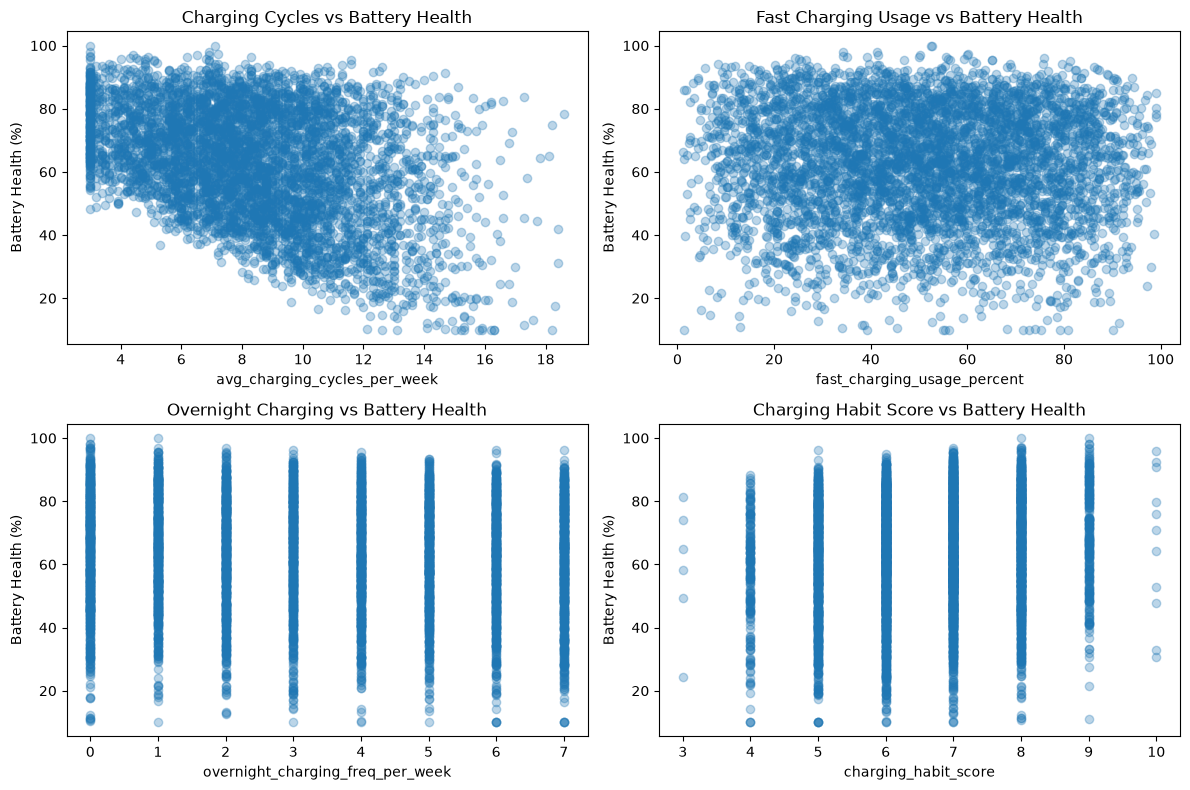

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

features = pd.read_excel(
    r"C:\Users\Lim Thong En\Downloads\smartphone_battery_features.xlsx"
)

targets = pd.read_excel(
    r"C:\Users\Lim Thong En\Downloads\smartphone_battery_targets.xlsx"
)

data = features.merge(targets, on="Device_ID")

charging_vars = [
    "avg_charging_cycles_per_week",
    "fast_charging_usage_percent",
    "overnight_charging_freq_per_week",
    "charging_habit_score"
]

titles = [
    "Charging Cycles vs Battery Health",
    "Fast Charging Usage vs Battery Health",
    "Overnight Charging vs Battery Health",
    "Charging Habit Score vs Battery Health"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, var, title in zip(axes.flatten(), charging_vars, titles):
    ax.scatter(
        data[var],
        data["current_battery_health_percent"],
        alpha=0.3
    )
    ax.set_xlabel(var)
    ax.set_ylabel("Battery Health (%)")
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [7]:
for var in charging_vars:
    corr = data[var].corr(
        data["current_battery_health_percent"]
    )
    print(f"{var}: {corr:.3f}")

avg_charging_cycles_per_week: -0.410
fast_charging_usage_percent: -0.033
overnight_charging_freq_per_week: -0.067
charging_habit_score: 0.138
